In [36]:
#!/usr/bin/env python3
# mmca_basin_scan.py
"""
Basin-of-attraction scan for MMCA on 3-uniform hypergraph.

What it does:
 - generate one random 3-uniform hypergraph (reuse_same_graph=True)
 - for each beta in beta_list:
     - for many initial rho0 values (log+linear grid), run MMCA until convergence
     - record steady rho_final( rho0 )
 - plot rho_final vs rho0 (log x axis), one curve per beta
 - optionally save CSV and PNG

Usage: edit parameters in the PARAMETERS block below, then run.
"""

import numpy as np
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from time import time

# -------------------------- Hypergraph generator --------------------------
def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = rng.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = rng.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

# -------------------------- MMCA model (same structure as yours) --------------------------
class HyperSISModel:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0]
        self.edge_j = self.hyperedges[:,1]
        self.edge_k = self.hyperedges[:,2]

        # node -> list of (edge_idx, pos)
        self.node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def _update_theta_from_p(self, p, Theta, eta, gamma):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_new = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        return np.clip(Theta_new, 0.0, 1.0), Phi

    def mmca_step(self, p, Theta, beta_d, mu, eta, gamma):
        # compute the "no-infection" Q node product
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        Q = np.ones(self.n, dtype=float)
        for node in range(self.n):
            prod_val = 1.0
            for (ei, pos) in self.node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_pos1[ei]
                else:
                    prod_oth = prod_pos2[ei]
                prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
            Q[node] = prod_val
        p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
        Theta_next, Phi = self._update_theta_from_p(p, Theta, eta, gamma)
        return p_next, Theta_next, Q, Phi

    def run_mmca_until_converged(self, beta_d, mu, eta, gamma,
                                 rho0=0.01, Theta0=1.0, tol=1e-9, max_iter=5000,
                                 record_traj=False):
        """
        Iterate MMCA until convergence; returns (rho_final, theta_mean_final, iters, (optional trajectories)).
        """
        p = np.full(self.n, float(rho0), dtype=float)
        Theta = np.full(self.m, float(Theta0), dtype=float)
        if record_traj:
            rho_hist = [p.mean()]
            theta_hist = [Theta.mean()]
        for it in range(max_iter):
            p_next, Theta_next, Q, Phi = self.mmca_step(p, Theta, beta_d, mu, eta, gamma)
            dp = np.max(np.abs(p_next - p))
            dTheta = np.max(np.abs(Theta_next - Theta))
            p, Theta = p_next, Theta_next
            if record_traj:
                rho_hist.append(p.mean()); theta_hist.append(Theta.mean())
            if dp < tol and dTheta < tol:
                break
        if record_traj:
            return float(p.mean()), float(Theta.mean()), int(it+1), np.array(rho_hist), np.array(theta_hist)
        else:
            return float(p.mean()), float(Theta.mean()), int(it+1)

# -------------------------- PARAMETERS (edit here) --------------------------
n = 1500
kappa = 6.0            # use kappa = 6 (change to 9 for another run)
seed = 12345           # seed for graph (use None for truly random)
MU = 0.1
ETA = 0.8
GAMMA = 0.02

# betas to test (choose a few around suspected bifurcation)
beta_list = [0.2]   # <-- 修改为你关心的 beta 列表
# rho0 grid: log-space small values + linear mid-large values
rho0_vals = np.concatenate([
    # np.logspace(-2, -1, 10),   # 1e-6 ... 1e-3 (log)
    np.linspace(0.1, 0.8, 36) # 0.1 ... 0.8 (linear)
])
rho0_vals = np.unique(np.clip(rho0_vals, 1e-12, 1.0))

# numerical tolerances
TOL = 1e-8
MAX_ITERS = 3000

# plotting / saving
OUT_DIR = "basin_scan_out"
save_csv = True
save_png = True
reuse_same_graph = True   # 强烈建议 True：在同一拓扑下测试不同初值以排除拓扑差异
# -------------------------------------------------------------------------------

# create output dir
import os
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------- prepare hypergraph --------------------------
print("Generating hypergraph (n={}, kappa={}) ...".format(n, kappa))
hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=seed, batch_size=3000)
model = HyperSISModel(hyperedges, n)
print("m (num edges) =", hyperedges.shape[0])

# -------------------------- run basin scans --------------------------
results = {}  # store arrays per beta
t0_all = time()
for beta in beta_list:
    print(f"\n--- Scanning beta = {beta} ---")
    rho_final = np.zeros_like(rho0_vals)
    theta_final = np.zeros_like(rho0_vals)
    iters_used = np.zeros_like(rho0_vals, dtype=int)

    # optionally warm-start from previously converged solution? here we do independent starts per rho0
    for i, rho0 in enumerate(rho0_vals):
        # run MMCA until converge starting from p_i(0) = rho0
        rf, thf, iters = model.run_mmca_until_converged(
            beta_d=beta, mu=MU, eta=ETA, gamma=GAMMA,
            rho0=rho0, Theta0=1.0, tol=TOL, max_iter=MAX_ITERS, record_traj=False
        )
        rho_final[i] = rf
        theta_final[i] = thf
        iters_used[i] = iters
        # small progress indicator every so often
        if (i % 20) == 0:
            print(f"  rho0={rho0:.1e} -> rho_final={rf:.6f} (iters={iters})")

    results[beta] = {
        'rho0_vals': rho0_vals.copy(),
        'rho_final': rho_final.copy(),
        'theta_final': theta_final.copy(),
        'iters': iters_used.copy()
    }
print("All scans done in {:.1f}s".format(time() - t0_all))

# -------------------- save CSVs (optional) --------------------
if save_csv:
    for beta in beta_list:
        df = pd.DataFrame({
            'rho0': results[beta]['rho0_vals'],
            'rho_final': results[beta]['rho_final'],
            'theta_final': results[beta]['theta_final'],
            'iters': results[beta]['iters']
        })
        fn = os.path.join(OUT_DIR, f"basin_kappa{int(kappa)}_beta{beta:.4f}.csv")
        df.to_csv(fn, index=False, float_format="%.6f")
        print("Saved", fn)


# -------------------- optional: a 'stacked' heatmap style view --------------------
# Build matrix: rows=rho0 index (log increasing), cols=beta values
# mat = np.vstack([results[beta]['rho_final'] for beta in beta_list]).T  # shape (len(rho0), len(beta_list))
# plt.figure(figsize=(7,6))
# im = plt.imshow(mat, aspect='auto', origin='lower',
#                 extent=[min(beta_list), max(beta_list), rho0_vals[0], rho0_vals[-1]],
#                 cmap='viridis')
# plt.yscale('log')
# plt.colorbar(im, label='rho_final')
# plt.xlabel('beta'); plt.ylabel('initial rho0 (log scale)')
# plt.title(f"rho_final heatmap (kappa={kappa})")
# plt.tight_layout()
# if save_png:
#     png_fn2 = os.path.join(OUT_DIR, f"basin_heatmap_kappa{int(kappa)}.png")
#     plt.savefig(png_fn2, dpi=300)
#     print("Saved heatmap", png_fn2)
# plt.show()


Generating hypergraph (n=1500, kappa=6.0) ...
m (num edges) = 3000

--- Scanning beta = 0.2 ---
  rho0=1.0e-01 -> rho_final=0.338596 (iters=1425)
  rho0=5.0e-01 -> rho_final=0.338596 (iters=1455)
All scans done in 115.1s
Saved basin_scan_out\basin_kappa6_beta0.2000.csv


Saved plot basin_scan_out\basin_kappa6_betas_1.png


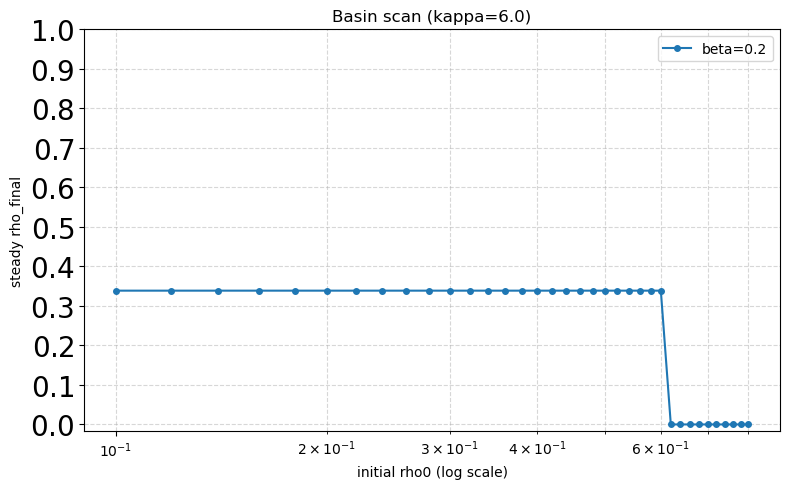

In [37]:
# -------------------- plotting: rho_final vs rho0 (log x) --------------------
plt.figure(figsize=(8,5))
colors = plt.get_cmap('tab10').colors
for idx, beta in enumerate(beta_list):
    rf = results[beta]['rho_final']
    plt.plot(rho0_vals, rf, '-o', ms=4, label=f"beta={beta}", color=colors[idx % len(colors)])
plt.xscale('log')
plt.xlabel("initial rho0 (log scale)")
plt.ylabel("steady rho_final")
plt.yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
           [r'$0.0$',r'$0.1$',r'$0.2$', r'$0.3$', r'$0.4$', r'$0.5$', r'$0.6$', r'$0.7$', r'$0.8$', r'$0.9$', r'$1.0$'], fontsize='20')
plt.title(f"Basin scan (kappa={kappa})")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
if save_png:
    png_fn = os.path.join(OUT_DIR, f"basin_kappa{int(kappa)}_betas_{len(beta_list)}.png")
    plt.savefig(png_fn, dpi=300)
    print("Saved plot", png_fn)
plt.show()
